# GNN Model Extraction Attack Demonstration
This notebook demonstrates the vulnerability of GNN-based fraud detection systems to model extraction attacks. We compare different adversary knowledge levels and visualize the results.

In [1]:
import torch as th
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from bank_data_loader import load_bank_data
from bank_attacks import run_attack
from bank_visualizer import plot_bank_network, plot_extracted_network
from synthetic_generator import generate_synthetic_bank_data

# Configuration
CSV_PATH = "bank_transaction_data_large.csv"
ATTACK_RATIO = 0.05 # Query 5% of nodes

/home/lonewolf/anaconda3/envs/dl/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 1. Dataset Preparation
We first ensure the large synthetic dataset exists. If not, we generate it.

In [2]:
import os
if not os.path.exists(CSV_PATH):
    print("Generating dataset...")
    generate_synthetic_bank_data(num_records=100000, fraud_rate=0.01, output_file=CSV_PATH)
else:
    print("Dataset already exists.")

Dataset already exists.


## 2. Running the Experiments
We compare three types of attacks:
- **Attack 1**: Low Knowledge (Partial Attr, Unknown Struct, Unknown Shadow)
- **Attack 3**: Medium Knowledge (Unknown Attr, Unknown Struct, Known Shadow)
- **Attack 6**: High Knowledge (Unknown Attr, Known Struct, Known Shadow)

In [3]:
attack_types = [1, 3, 6]
results = {}
extracted_data = {}

for atype in attack_types:
    print(f"Executing Attack {atype}...")
    model, adv_g, adv_feat, fidelity = run_attack(
        atype, CSV_PATH, ATTACK_RATIO, sampling_strategy="random"
    )
    results[atype] = fidelity
    extracted_data[atype] = (adv_g, adv_feat)
    print(f"Attack {atype} Fidelity: {fidelity:.4f}")

Executing Attack 1...
Training Target Model for Attack 1...
Target Model Accuracy: 0.9804
Executing Attack 1 ({'attr': 'partial', 'struct': 'unknown', 'shadow': 'unknown'})
Attack 1 Fidelity: 0.0197
Attack 1 Fidelity: 0.0197
Executing Attack 3...
Training Target Model for Attack 3...
Target Model Accuracy: 0.9782
Executing Attack 3 ({'attr': 'unknown', 'struct': 'unknown', 'shadow': 'known'})
Pre-training surrogate on Shadow Dataset...
Attack 3 Fidelity: 0.9782
Attack 3 Fidelity: 0.9782
Executing Attack 6...
Training Target Model for Attack 6...
Target Model Accuracy: 0.9280
Executing Attack 6 ({'attr': 'unknown', 'struct': 'known', 'shadow': 'known'})
Pre-training surrogate on Shadow Dataset...
Attack 6 Fidelity: 0.8412
Attack 6 Fidelity: 0.8412


## 3. Result Analysis
We plot the fidelity of the surrogate models against the knowledge level.

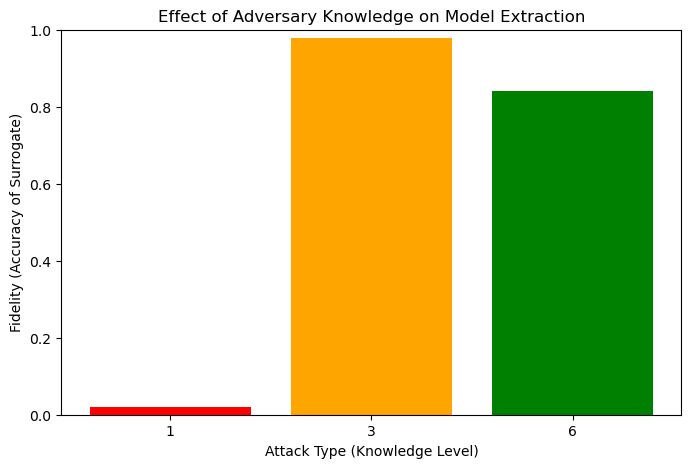

In [4]:
plt.figure(figsize=(8, 5))
plt.bar([str(k) for k in results.keys()], results.values(), color=['red', 'orange', 'green'])
plt.xlabel("Attack Type (Knowledge Level)")
plt.ylabel("Fidelity (Accuracy of Surrogate)")
plt.title("Effect of Adversary Knowledge on Model Extraction")
plt.ylim(0, 1.0)
plt.show()

## 4. Network Visualization
Finally, we visualize the adversary's view of the network for the high-knowledge attack vs. the low-knowledge attack.

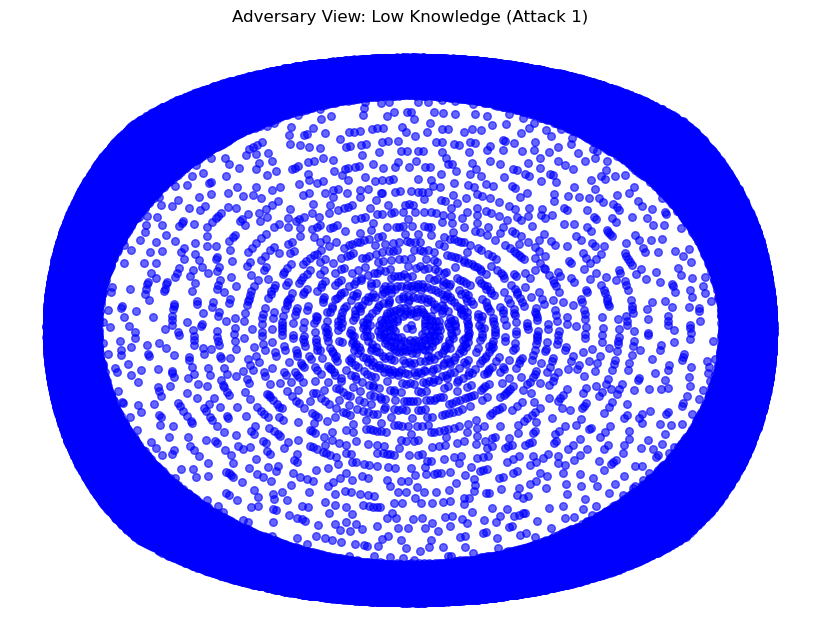

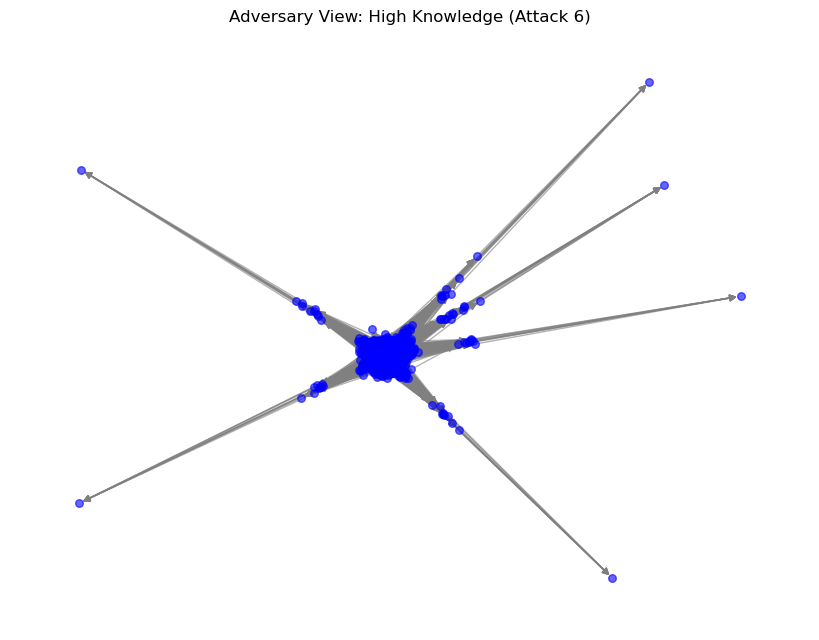

In [5]:
# Plot Low Knowledge (Attack 1)
adv_g_low, _ = extracted_data[1]
plot_extracted_network(adv_g_low, title="Adversary View: Low Knowledge (Attack 1)")

# Plot High Knowledge (Attack 6)
adv_g_high, _ = extracted_data[6]
plot_extracted_network(adv_g_high, title="Adversary View: High Knowledge (Attack 6)")